# Notebook 01
A random walk is the process where a particle moves randomly over time. For each step, the walker changes position depending on the previous position. This can be modeled using the equation

$X_{n+1} = X_n + Z_n$

where $X_n$ is the current position, $Z_n$ si the random increment (step) and $X_{n+1}$ is the next position.

A Gaussian increment is when $Z_n$ is specified as $Z_n \sim \mathcal{N}(0, 1)$. Every step is sampled from a standard normal distribution (mean = 0, variance = 1). Mean is the average value of a set of numbers and variance is the statistical measure of how far a set of numbers are spread out from the mean. The values of a Gaussian increment are continuous.

In [182]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

## Implement 1D random walk
A 1D random walk is unique in how long each random walk is and how many independent random walks are simulated. These are the parameters of the function, called T and N, respectively.

The starting position of every walker (one independent random walk that is simulated) must be 0. To later plot the trajectories of the walkers, their position at every point in time must be stored. They are stored in an array.

For each time step in the length of the walk, the next position is based on the previous position, but also includes a Gaussian step (a random change in the position). This is modeled in the equation $X_{n+1} = X_n + Z_n$, where $X_{n+1}$ is the next position, $X_n$ is the current position and $Z_n$ is the Gaussian step. When $Z_n \sim \mathcal{N}(0, 1)$, the Gaussian step is a continuous value on a normal distribution with mean equal to 0 and variance equal to 1. Varaince is how far the set of numbers is spread around the mean. $Z_n$ must be a value from the standard normal distribution of numbers because only the standard normal distribution has a variance of 1.

The process of calculating the next position from the previous position and the addition of the Gaussian step is repeated for the entirety of the length of the walk. In NumPy, arrays are mutable objects. However, lists store references to their elements, so each position added to the list must be a copy of the position. If no copies were made, the elements in the list would be identical (equal to the last value added) because the references (pointers) are pointing to the last element.



In [183]:
# 1D Random Walk
def one_dim_walk(T, N):
    current_pos = np.zeros(N) # All walkers start at 0
    pos_arr = [] # List of all positions over time
    
    for step in range(T):
        # Generate a Gaussian step for each walker
        gaussian_step = np.random.normal(0, 1, size=N)
        
        # Add the Gaussian step to the current position
        current_pos += gaussian_step
        
        # Add a copy of the updated current position to the array of all positions over time
        pos_arr.append(current_pos.copy())
        
    return np.array(pos_arr)
    

## Implement 2D random walk
A 2D random walk is identical to a 1D random walk except that it has an x coordinate and y coordinate for its position instead of just one coordinate for its position.

The parameters must be the same: the length of time the walk is (T) and how many independent random walks are simulated (N). The current position begins with an x coordinate of 0 and a y coordinate of 0. However, the calculation for the Gaussian step involves randomly selecting a number for both the x coordinate and the y coordinate. This can be done by setting the size of x to N and the size of y to N.

The process of calculating the next position from the previous position and the addition of the Gaussian step is repeated for the entirety of the length of the walk. Similar to the 1D random walk, a copy of the position is added to the list of all the positions over time.

In [184]:
# 2D Random Walk
def two_dim_walk(T, N):
    current_pos = np.zeros((N, 2)) # All walkers start at 0, with each walker having a position comprised of an x and y coordinate
    pos_arr = [] # List of all positions over time, with each position having an x and y coordinate
    
    for step in range(T):
        # Generate a Gaussian step for each coordinate of the walker's position
        gaussian_step = np.random.normal(0, 1, size=(N, 2))
        
        # Add the Gaussian step to the current position
        current_pos += gaussian_step
        
        # Add a copy of the updated current position to the array of all positions over time
        pos_arr.append(current_pos.copy())
        
    return np.array(pos_arr)

## Numerically verify the CLT
An empirical distribution is derived from experimental results instead of assumptions. To plot empirical distributions of $X_T$ for T=100 and N=100, 1000, 10000, we run 1D and 2D random walks with those parameter values.

A normal distribution has the expression $X_T \sim \mathcal{N}(0, T)$, where $X_T$ the position of $X$ at time T, the mean is equal to 0, and the variance is equal to T. As time increases, the variance will increase.

Since $X_T$ is the position of $X$ at time T, we only look at the final position of the walker at time T. This can be done by storing the elements in the final row of the array of the x-values for a certain T and N value.

The histogram of the final row x-values must not show raw frequency counts, but instead probability density if we want to later compare the plot to a Gaussian curve. Probability density is the likeliness of measuring a specific value for a continuous variable. A Gaussian curve (also known as a normal distribution) is centered around 0 because it has a mean of 0. The curve is also perfectly symmetrical. To normalize the final row x-values and compare the distribution to a Gaussian curve, we set density to True, ensuring the total area under the bars is 1.

To create a reference to verify the Central Limit Theorem (CLT), this curve must be plotted alongside the Gaussian curve. To create the Gaussian curve for the specific T and N values being plotted, we generate evenly spaced x-values between the minimum and maximum of the array of the final row of original x-values. Then, we compute the Gaussian values of each x-value, otherwise known as finding the probability of each x-value being chosen. Now that both the histogram of final row x-values and the Gaussian curve are plotted, the resemblance can be compared for different N values.

As the N value increases, the x-values from the simulation more closely resemble a Gaussian curve. Each walker can be expressed as $X_{T}^{(i)}$ where $i$ is the index of the walker. So, with N walkers, there is an empirical distribution that can be expressed as $X_{T}^{(1)}, X_{T}^{(2)},..., X_{T}^{(N)}$.

The walk of a specific T and N value can also be written as $X_T = \sum_{k=1}^{T} Z_k$ where each step is a Gaussian step expressed as $Z_{k} \sim \mathcal{N}(0, 1)$. The sum of independent Gaussian steps is Gaussian, so $X_{T} \sim \mathcal{N}(0, T)$. Therefore, increasing the value of N more closely resembles the true shape of a Gaussian curve.

When N is a small value (such as 100), there are only 100 walkers, so the random fluctations can be large and there is noise. When N is a large value (such as 10000), there are 10000 walkers and the randomness averages out. Therefore, increasing the value of N more closely resembles the true shape of a Gaussian curve since there are more walks and the walks are Gaussian.

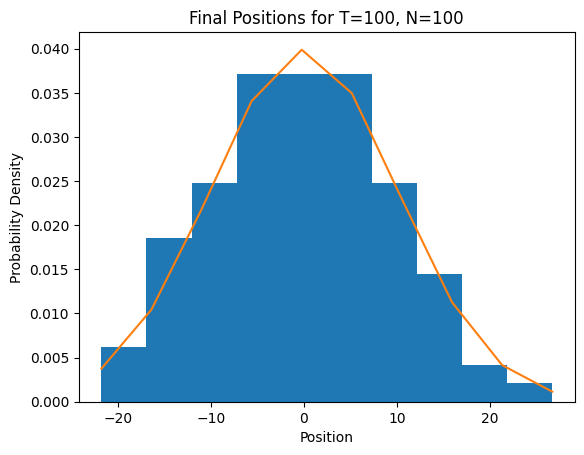

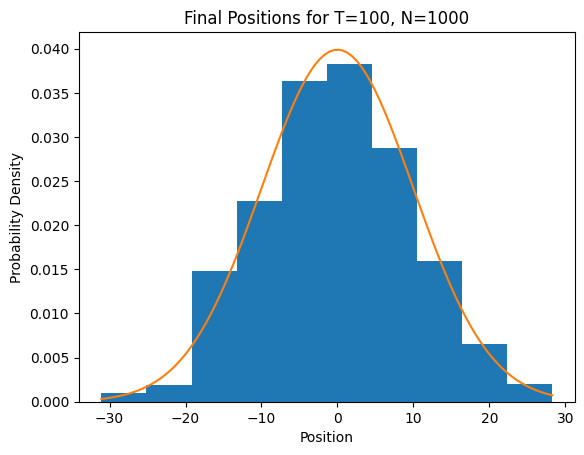

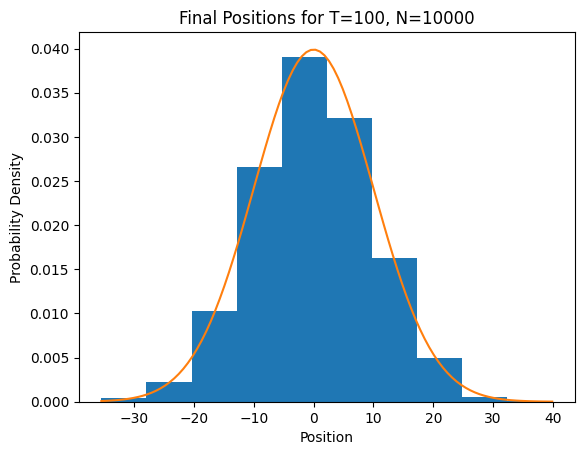

In [185]:
# Run simulations for T=100 and N=100, 1000, 10000
# Simulation for T=100, N=100
arr_hundred = one_dim_walk(100, 100)
last_row_hundred = arr_hundred[-1]
    
# Simulation for T=100, N=1000
arr_thousand = one_dim_walk(100, 1000)
last_row_thousand = arr_thousand[-1]
    
# Simulation for T=100, N=10000
arr_ten_thousand = one_dim_walk(100, 10000)
last_row_ten_thousand = arr_ten_thousand[-1]
    
    
# Plot histograms of final positions of each simulation
# Plot histogram for T=100, N=100
plt.hist(last_row_hundred, density=True) # Normalize using density=True to display probability density instead of raw frequency counts
plt.title('Final Positions for T=100, N=100')
plt.xlabel('Position')
plt.ylabel('Frequency')
    
# Compute evenly spaced x-values
x_values = np.linspace(min(last_row_hundred), max(last_row_hundred), 10)
# Compute Gaussian density at each x-value
gaussian_values = norm.pdf(x_values, 0, 10)
    
# Plot Gaussian curve for T=100, N=100
plt.plot(x_values, gaussian_values)
plt.title('Final Positions for T=100, N=100')
plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.show()
    
# Plot histogram for T=100, N=1000
plt.hist(last_row_thousand, density=True) # Normalize using density=True to display probability density instead of raw frequency counts
plt.title('Final Positions for T=100, N=1000')
plt.xlabel('Position')
plt.ylabel('Frequency')
    
# Compute evenly spaced x-values
x_values = np.linspace(min(last_row_thousand), max(last_row_thousand), 100)
# Compute Gaussian density for each x-value
gaussian_values = norm.pdf(x_values, 0, 10)
    
# Plot Gaussian curve for T=100, N=1000
plt.plot(x_values, gaussian_values)
plt.title('Final Positions for T=100, N=1000')
plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.show()
    
# Plot histogram for T=100, N=10000
plt.hist(last_row_ten_thousand, density=True) # Normalize using density=True to display probability density instead of raw frequency counts
plt.title('Final Positions for T=100, N=10000')
plt.xlabel('Position')
plt.ylabel('Frequency')
    
# Compute evenly spaced x-values
x_values = np.linspace(min(last_row_ten_thousand), max(last_row_ten_thousand), 100)
# Compute Gaussian density for each x-value
gaussian_values = norm.pdf(x_values, 0, 10)
    
# Plot Gaussian curve for T=100, N=10000
plt.plot(x_values, gaussian_values)
plt.title('Final Positions for T=100, N=10000')
plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.show()

## Write unit tests for random walk functions

In [186]:
# Test E[X_T]=0 (within tolerance) for T=100, N=100
average = np.mean(last_row_hundred)
print(f"E[X_T] for T=100, N=100: {average}")
tolerance = 2 * (math.sqrt(100) / math.sqrt(100)) # 2 standard errors of the mean
assert abs(average - 0) < tolerance

# Test E[X_T]=0 (within tolerance) for T=100, N=1000
average = np.mean(last_row_thousand)
print(f"E[X_T] for T=100, N=1000: {average}")
tolerance = 2 * (math.sqrt(100) / math.sqrt(1000)) # 2 standard errors of the mean
assert abs(average - 0) < tolerance

# Test E[X_T]=0 (within tolerance) for T=100, N=10000
average = np.mean(last_row_ten_thousand)
print(f"E[X_T] for T=100, N=10000: {average}")
tolerance = 2 * (math.sqrt(100) / math.sqrt(10000)) # 2 standard errors of the mean
assert abs(average - 0) < tolerance

# Test Var[X_T]=T (within tolerance) for T=100, N=100
variance = np.var(last_row_hundred)
print(f"Var[X_T] for T=100, N=100: {variance}")
tolerance = 0.1 * 100 # 10% tolerance
assert abs(variance - 100) < tolerance

# Test Var[X_T]=T (within tolerance) for T=100, N=1000
variance = np.var(last_row_thousand)
print(f"Var[X_T] for T=100, N=1000: {variance}")
tolerance = 0.1 * 1000 # 10% tolerance
assert abs(variance - 100) < tolerance

# Test Var[X_T]=T (within tolerance) for T=100, N=10000
variance = np.var(last_row_ten_thousand)
print(f"Var[X_T] for T=100, N=10000: {variance}")
tolerance = 0.1 * 10000 # 10% tolerance
assert abs(variance - 100) < tolerance

E[X_T] for T=100, N=100: -0.06372722554797637
E[X_T] for T=100, N=1000: -0.16797957440591255
E[X_T] for T=100, N=10000: -0.09768231266382804
Var[X_T] for T=100, N=100: 91.72029382793502
Var[X_T] for T=100, N=1000: 98.483400316848
Var[X_T] for T=100, N=10000: 99.4850196624127
